In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [9]:
theta = np.linspace(0, 2 * np.pi, 100)
radius = 3
x_circle = radius * np.cos(theta)
y_circle = radius * np.sin(theta)
data = np.stack((x_circle, y_circle), axis=1)
data = torch.tensor(data, dtype=torch.float32)

In [10]:
batch_size = 10
dataset_loader = DataLoader(
    TensorDataset(data),
    batch_size=batch_size,
    shuffle=True
)

In [11]:
class VAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [12]:
def vae_loss(recon_x, x, mu, logvar, recon_weight=10):
    recon_loss = recon_weight * nn.MSELoss()(recon_x, x)
    kl_div = -0.05 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div / x.size(0)

In [13]:
input_dim = 2
latent_dim = 2

vae = VAE(input_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

num_epochs = 1000

for epoch in range(num_epochs):
    vae.train()
    total_loss = 0

    for batch in dataset_loader:
        batch_data = batch[0]

        optimizer.zero_grad()
        recon_data, mu, logvar = vae(batch_data)

        loss = vae_loss(recon_data, batch_data, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 100 == 0:
        avg_loss = total_loss / len(dataset_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [100/1000], Loss: 0.8051
Epoch [200/1000], Loss: 0.7269
Epoch [300/1000], Loss: 0.7196
Epoch [400/1000], Loss: 0.7163
Epoch [500/1000], Loss: 0.6975
Epoch [600/1000], Loss: 0.6946
Epoch [700/1000], Loss: 0.6811
Epoch [800/1000], Loss: 0.6895
Epoch [900/1000], Loss: 0.6806
Epoch [1000/1000], Loss: 0.6919


In [14]:
vae.eval()
reconstructed_data = []

with torch.no_grad():
    for batch in dataset_loader:
        batch_data = batch[0]
        recon_batch, _, _ = vae(batch_data)
        reconstructed_data.append(recon_batch)

reconstructed_data = torch.cat(reconstructed_data).numpy()
data_np = data.numpy()

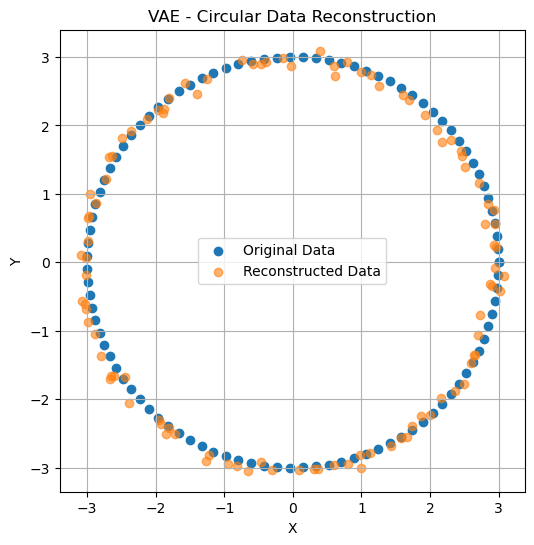

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], label="Original Data")
plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1],
            alpha=0.6, label="Reconstructed Data")
plt.legend()
plt.title("VAE - Circular Data Reconstruction")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()